In [35]:
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import timm
import torch.nn as nn
import torch
import torch.optim as optim

In [61]:
import sys
sys.path.append("../src")

# Force reload the updated gradcam.py (so your fix is used)
import importlib
import gradcam
importlib.reload(gradcam)
from gradcam import GradCAM

import os
import cv2
from PIL import Image
import numpy as np

In [37]:
# Load a few images without transforms (to show originals)
data_path = "../data/archive/Training"
dataset = datasets.ImageFolder(root=data_path)

In [38]:
# Class names
class_names = dataset.classes
print("Classes:", class_names)


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


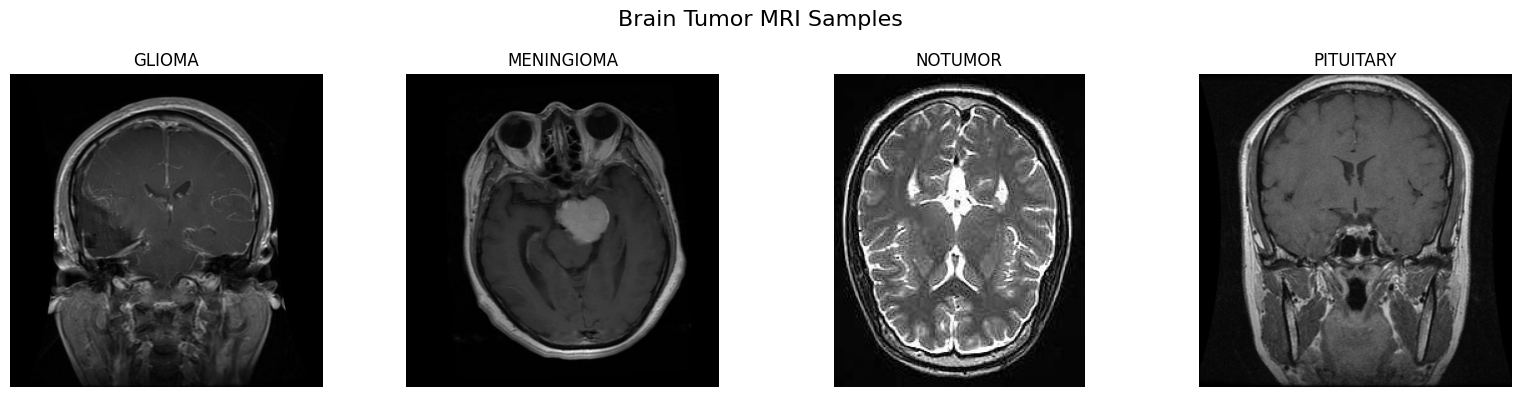

In [39]:
# Show 1 image from each class

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Brain Tumor MRI Samples", fontsize=16)

found_classes = set()
for img, label in dataset:
    class_name = class_names[label]
    if class_name not in found_classes and len(found_classes) < 4:
        ax = axes[len(found_classes)]
        ax.imshow(img)
        ax.set_title(class_name.upper(), fontsize=12)
        ax.axis("off")
        found_classes.add(class_name)
    if len(found_classes) == 4:
        break

plt.tight_layout()
plt.show()


In [40]:
# Step 1: Define image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),      # Make all images 224x224 pixels
    transforms.ToTensor(),               # Convert image to numbers PyTorch understands
    transforms.Normalize((0.5,), (0.5,)) # Scale pixel values to [-1, 1]
])

In [41]:
# Step 2: Load training data WITH preprocessing
train_path = "../data/archive/Training"
full_dataset = datasets.ImageFolder(root=train_path, transform=transform)

print(f"Total training images: {len(full_dataset)}")
print(f"Classes: {full_dataset.classes}")

Total training images: 5600
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [42]:
# Step 3: Split into Train (90%) and Validation (10%)
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print(f"Train: {len(train_dataset)}, Validation: {len(val_dataset)}")

Train: 5040, Validation: 560


In [43]:
# Step 4: Load test data
test_path = "../data/archive/Testing"
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)
print(f"Test: {len(test_dataset)}")

Test: 1600


In [44]:
# Step 5: Create DataLoaders (batches of 32 images)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("\nData ready for training!")


Data ready for training!


In [45]:
# Step 1: Set device (use Mac GPU if available)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")


Using device: mps


In [46]:
# MUCH faster model: ResNet-18 (11M parameters vs 27M)
model = timm.create_model(
    'resnet18',
    pretrained=True,
    num_classes=4
)

In [47]:
# Step 3: Move model to device
model = model.to(device)

print("Model loaded!")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

Model loaded!
Number of parameters: 11,178,564


In [48]:
# Step 1: Loss function — tells us how wrong the model is
criterion = nn.CrossEntropyLoss()

# Step 2: Optimizer — updates the model weights to reduce loss
# lr = learning rate = how big a step to take (0.0001 = small careful steps)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print("Loss function: CrossEntropyLoss")
print("Optimizer: Adam with learning rate 0.0001")

Loss function: CrossEntropyLoss
Optimizer: Adam with learning rate 0.0001


In [64]:
epochs = 10  # We'll do 2 rounds first (takes ~10-15 min on Mac)

for epoch in range(epochs):
    # -------- TRAINING PHASE --------
    model.train()  # Tell model: "you are learning now"
    train_loss = 0.0
    
    for images, labels in train_loader:
        # Move data to Mac GPU
        images = images.to(device)
        labels = labels.to(device)
        
        # 1. Forward pass: model looks at images and makes predictions
        outputs = model(images)
        
        # 2. Calculate how wrong the model was
        loss = criterion(outputs, labels)
        
        # 3. Backward pass: figure out which weights to change
        optimizer.zero_grad()  # Clear old gradients
        loss.backward()        # Calculate new gradients
        
        # 4. Update weights: take a small step in the right direction
        optimizer.step()
        
        train_loss += loss.item()
    
    # Average training loss for this epoch
    avg_train_loss = train_loss / len(train_loader)
    
    # -------- VALIDATION PHASE --------
    model.eval()  # Tell model: "just check, don't learn"
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():  # Don't calculate gradients (faster)
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            # Count how many predictions were correct
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total
    
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Accuracy: {val_accuracy:.2f}%")

print("\nTraining complete!")

Epoch [1/10] Train Loss: 0.0442 | Val Loss: 0.0834 | Val Accuracy: 97.68%
Epoch [2/10] Train Loss: 0.0283 | Val Loss: 0.0474 | Val Accuracy: 98.39%
Epoch [3/10] Train Loss: 0.0237 | Val Loss: 0.0629 | Val Accuracy: 98.04%
Epoch [4/10] Train Loss: 0.0200 | Val Loss: 0.0468 | Val Accuracy: 98.04%
Epoch [5/10] Train Loss: 0.0149 | Val Loss: 0.0410 | Val Accuracy: 99.11%
Epoch [6/10] Train Loss: 0.0122 | Val Loss: 0.0425 | Val Accuracy: 98.57%
Epoch [7/10] Train Loss: 0.0093 | Val Loss: 0.0865 | Val Accuracy: 97.14%
Epoch [8/10] Train Loss: 0.0080 | Val Loss: 0.0419 | Val Accuracy: 98.57%
Epoch [9/10] Train Loss: 0.0105 | Val Loss: 0.0638 | Val Accuracy: 98.39%
Epoch [10/10] Train Loss: 0.0086 | Val Loss: 0.0687 | Val Accuracy: 97.86%

Training complete!


In [50]:
# Final test on 1,600 images the model NEVER saw
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Final Test Accuracy: {test_accuracy:.2f}%")
print(f"Correct: {correct}/{total}")

Final Test Accuracy: 93.19%
Correct: 1491/1600


In [51]:
# Save the trained model weights
torch.save(model.state_dict(), "../results/brain_tumor_resnet18.pth")
print("Model saved to: results/brain_tumor_resnet18.pth")

Model saved to: results/brain_tumor_resnet18.pth


In [57]:
test_glioma_path = "../data/archive/Testing/glioma"
files = os.listdir(test_glioma_path)
print("Files in Testing/glioma:")
print(files[:5])  # Show first 5 files

Files in Testing/glioma:
['Te-gl_218.jpg', 'Te-gl_224.jpg', 'Te-gl_230.jpg', 'Te-gl_152.jpg', 'Te-gl_146.jpg']


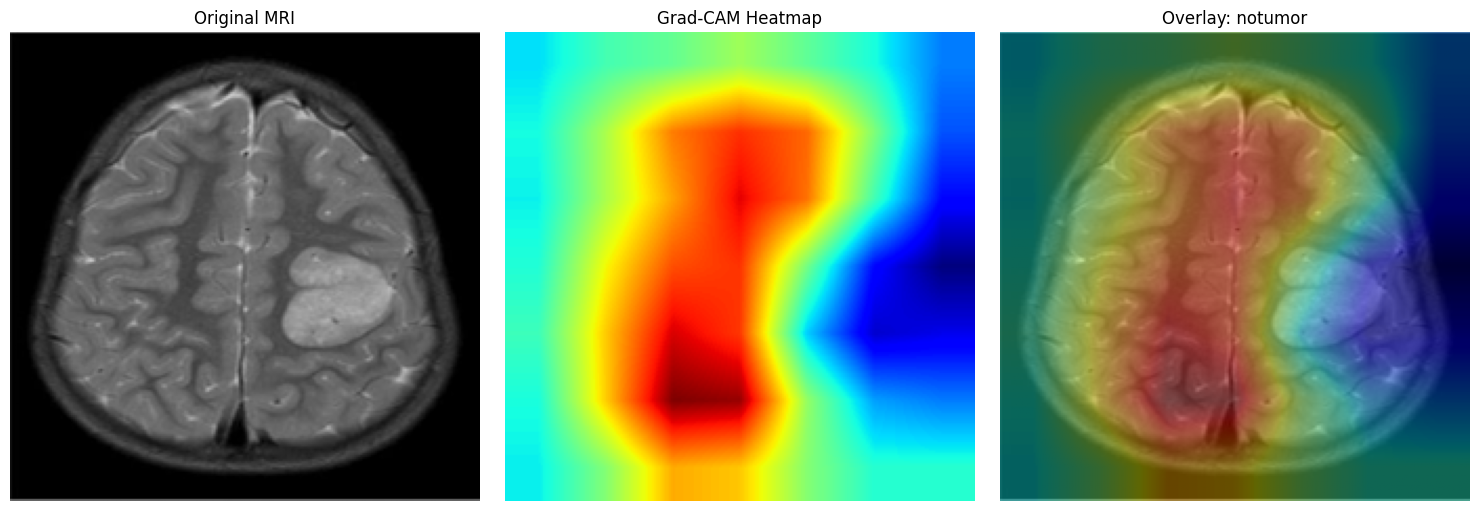

In [63]:
# Pick one image from test set
test_image_path = "../data/archive/Testing/glioma/Te-gl_218.jpg"
img = Image.open(test_image_path).convert('RGB')

# Preprocess
input_tensor = transform(img).unsqueeze(0).to(device)

# Find the last convolutional layer in ResNet-18
target_layer = model.layer4[1].conv2

# Generate Grad-CAM
gradcam = GradCAM(model, target_layer)
cam, predicted_class = gradcam.generate(input_tensor)

# Resize CAM to image size
cam = cv2.resize(cam, (224, 224))

# Create heatmap
heatmap = plt.cm.jet(cam)[:, :, :3]

# Overlay on original image
img_array = np.array(img.resize((224, 224))) / 255.0
overlay = 0.6 * img_array + 0.4 * heatmap

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_array)
axes[0].set_title("Original MRI")
axes[0].axis("off")

axes[1].imshow(heatmap)
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title(f"Overlay: {full_dataset.classes[predicted_class]}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [62]:
# Create folder for Grad-CAM examples
os.makedirs("../results/gradcam_examples", exist_ok=True)

# Create ONE Grad-CAM instance (reused for all images)
gradcam = GradCAM(model, model.layer4[1].conv2)

# Test one image from each class
test_paths = {
    "glioma": "../data/archive/Testing/glioma/Te-gl_218.jpg",
    "meningioma": "../data/archive/Testing/meningioma/Te-me_218.jpg",
    "notumor": "../data/archive/Testing/notumor/Te-no_218.jpg",
    "pituitary": "../data/archive/Testing/pituitary/Te-pi_218.jpg"
}

for class_name, img_path in test_paths.items():
    if not os.path.exists(img_path):
        print(f"Skipping {class_name}: file not found")
        continue
    
    # Load and predict
    img = Image.open(img_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)
    
    cam, predicted = gradcam.generate(input_tensor)
    cam = cv2.resize(cam, (224, 224))
    heatmap = plt.cm.jet(cam)[:, :, :3]
    img_array = np.array(img.resize((224, 224))) / 255.0
    overlay = 0.6 * img_array + 0.4 * heatmap
    
    pred_name = full_dataset.classes[predicted]
    
    # Save figure
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_array); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(heatmap); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
    axes[2].imshow(overlay); axes[2].set_title(f"Predicted: {pred_name}"); axes[2].axis("off")
    
    save_path = f"../results/gradcam_examples/{class_name}_pred_{pred_name}.png"
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.close()
    
    print(f"Saved: {class_name} -> predicted as {pred_name}")

print("\nAll examples saved to results/gradcam_examples/")

Saved: glioma -> predicted as notumor
Saved: meningioma -> predicted as meningioma
Saved: notumor -> predicted as notumor
Saved: pituitary -> predicted as pituitary

All examples saved to results/gradcam_examples/
